In [1]:
!pip install gdown

In [2]:
!pip install transformers[torch]
!pip install accelerate==0.22.3
!pip install -q datasets jiwer

ERROR: Could not find a version that satisfies the requirement accelerate==0.22.3 (from versions: 0.0.1, 0.1.0, 0.2.0, 0.2.1, 0.3.0, 0.4.0, 0.5.0, 0.5.1, 0.6.0, 0.6.1, 0.6.2, 0.7.0, 0.7.1, 0.8.0, 0.9.0, 0.10.0, 0.11.0, 0.12.0, 0.13.0, 0.13.1, 0.13.2, 0.14.0, 0.15.0, 0.16.0, 0.17.0, 0.17.1, 0.18.0, 0.19.0, 0.20.0, 0.20.1, 0.20.2, 0.20.3, 0.21.0, 0.22.0)
ERROR: No matching distribution found for accelerate==0.22.3


In [3]:
!gdown --id 1b4fCTrnfKnR0GHm1XCve9nhy7JyrqahR

/opt/conda/lib/python3.10/site-packages/gdown/cli.py:126: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=1b4fCTrnfKnR0GHm1XCve9nhy7JyrqahR
To: /kaggle/working/train_gt.txt
100%|███████████████████████████████████████| 2.79M/2.79M [00:00<00:00, 203MB/s]


In [4]:
import pandas as pd

df = pd.read_csv('/kaggle/working/train_gt.txt', sep = '\t',header=None)
df.rename(columns={0: "file_name", 1: "text"}, inplace=True)
df['text'] = df['text'].apply(str)
df.head()

,file_name,text
0,train_img_0.jpg,Thỗn
1,train_img_1.jpg,May-So
2,train_img_2.jpg,nhẹn
3,train_img_3.jpg,hàu
4,train_img_4.jpg,Quấy


In [5]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(df, test_size=0.05)
# we reset the indices to start from zero
train_df.reset_index(drop=True, inplace=True)
test_df.reset_index(drop=True, inplace=True)

/opt/conda/lib/python3.10/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.23.5
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [6]:
import torch
from torch.utils.data import Dataset
from PIL import Image

class IAMDataset(Dataset):
    def __init__(self, root_dir, df, processor, max_target_length=128):
        self.root_dir = root_dir
        self.df = df
        self.processor = processor
        self.max_target_length = max_target_length

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        # get file name + text
        file_name = self.df['file_name'][idx]
        text = self.df['text'][idx]
        # prepare image (i.e. resize + normalize)
        image = Image.open(self.root_dir + file_name).convert("RGB")
        pixel_values = self.processor(image, return_tensors="pt").pixel_values
        # add labels (input_ids) by encoding the text
        labels = self.processor.tokenizer(text,
                                          padding="max_length",
                                          max_length=self.max_target_length).input_ids
        # important: make sure that PAD tokens are ignored by the loss function
        labels = [label if label != self.processor.tokenizer.pad_token_id else -100 for label in labels]

        encoding = {"pixel_values": pixel_values.squeeze(), "labels": torch.tensor(labels)}
        return encoding

In [7]:
from transformers import TrOCRProcessor

processor = TrOCRProcessor.from_pretrained("microsoft/trocr-base-handwritten")
train_dataset = IAMDataset(root_dir='/kaggle/input/train-ocr/new_train/',
                           df=train_df,
                           processor=processor)
eval_dataset = IAMDataset(root_dir='/kaggle/input/train-ocr/new_train/',
                           df=test_df,
                           processor=processor)

Could not find image processor class in the image processor config or the model config. Loading based on pattern matching with the model's feature extractor configuration.
/opt/conda/lib/python3.10/site-packages/tensorflow_io/python/ops/__init__.py:98: UserWarning: unable to load libtensorflow_io_plugins.so: unable to open file: libtensorflow_io_plugins.so, from paths: ['/opt/conda/lib/python3.10/site-packages/tensorflow_io/python/ops/libtensorflow_io_plugins.so']
caused by: ['/opt/conda/lib/python3.10/site-packages/tensorflow_io/python/ops/libtensorflow_io_plugins.so: undefined symbol: _ZN3tsl6StatusC1EN10tensorflow5error4CodeESt17basic_string_viewIcSt11char_traitsIcEENS_14SourceLocationE']
  warnings.warn(f"unable to load libtensorflow_io_plugins.so: {e}")
/opt/conda/lib/python3.10/site-packages/tensorflow_io/python/ops/__init__.py:104: UserWarning: file system plugins are not loaded: unable to open file: libtensorflow_io.so, from paths: ['/opt/conda/lib/python3.10/site-packages/tens

Number of training examples: 97850
Number of validation examples: 5150
pixel_values torch.Size([3, 384, 384])
labels torch.Size([128])
Mươi


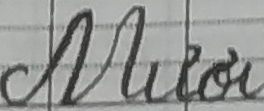

In [8]:
print("Number of training examples:", len(train_dataset))
print("Number of validation examples:", len(eval_dataset))
encoding = train_dataset[0]
for k,v in encoding.items():
  print(k, v.shape)
labels = encoding['labels']
labels[labels == -100] = processor.tokenizer.pad_token_id
label_str = processor.decode(labels, skip_special_tokens=True)
print(label_str)
image = Image.open(train_dataset.root_dir + train_df['file_name'][0]).convert("RGB")
image

In [9]:
from transformers import VisionEncoderDecoderModel

model = VisionEncoderDecoderModel.from_pretrained("/kaggle/input/ckpt-trocr-2000")
# set special tokens used for creating the decoder_input_ids from the labels
model.config.decoder_start_token_id = processor.tokenizer.cls_token_id
model.config.pad_token_id = processor.tokenizer.pad_token_id
# make sure vocab size is set correctly
model.config.vocab_size = model.config.decoder.vocab_size

# set beam search parameters
model.config.eos_token_id = processor.tokenizer.sep_token_id
model.config.max_length = 64
model.config.early_stopping = True
model.config.no_repeat_ngram_size = 3
model.config.length_penalty = 2.0
model.config.num_beams = 4

In [10]:
from transformers import Seq2SeqTrainer, Seq2SeqTrainingArguments

training_args = Seq2SeqTrainingArguments(
    predict_with_generate=True,
    evaluation_strategy="steps",
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    fp16=True,
    output_dir="./",
    logging_steps=2,
    save_steps=1000,
    eval_steps=200,
)

In [11]:
from datasets import load_metric

cer_metric = load_metric("cer")

def compute_metrics(pred):
    labels_ids = pred.label_ids
    pred_ids = pred.predictions

    pred_str = processor.batch_decode(pred_ids, skip_special_tokens=True)
    labels_ids[labels_ids == -100] = processor.tokenizer.pad_token_id
    label_str = processor.batch_decode(labels_ids, skip_special_tokens=True)

    cer = cer_metric.compute(predictions=pred_str, references=label_str)

    return {"cer": cer}

In [12]:
from transformers import default_data_collator

# instantiate trainer
trainer = Seq2SeqTrainer(
    model=model,
    tokenizer=processor.feature_extractor,
    args=training_args,
    compute_metrics=compute_metrics,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    data_collator=default_data_collator,
)
trainer.train()

/opt/conda/lib/python3.10/site-packages/transformers/models/trocr/processing_trocr.py:134: FutureWarning: `feature_extractor` is deprecated and will be removed in v5. Use `image_processor` instead.
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/transformers/optimization.py:411: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(


╭─────────────────────────────── Traceback (most recent call last) ────────────────────────────────╮
│ in <module>:13                                                                                   │
│                                                                                                  │
│   10 │   eval_dataset=eval_dataset,                                                              │
│   11 │   data_collator=default_data_collator,                                                    │
│   12 )                                                                                           │
│ ❱ 13 trainer.train()                                                                             │
│   14                                                                                             │
│                                                                                                  │
│ /opt/conda/lib/python3.10/site-packages/transformers/trainer.py:1645 in train                    │
│                                                                                                  │
│   1642 │   │   inner_training_loop = find_executable_batch_size(                                 │
│   1643 │   │   │   self._inner_training_loop, self._train_batch_size, args.auto_find_batch_size  │
│   1644 │   │   )                                                                                 │
│ ❱ 1645 │   │   return inner_training_loop(                                                       │
│   1646 │   │   │   args=args,                                                                    │
│   1647 │   │   │   resume_from_checkpoint=resume_from_checkpoint,                                │
│   1648 │   │   │   trial=trial,                                                                  │
│                                                                                                  │
│ /opt/conda/lib/python3.10/site-packages/transformers/trainer.py:1862 in _inner_training_loop     │
│                                                                                                  │
│   1859 │   │   self._globalstep_last_logged = self.state.global_step                             │
│   1860 │   │   model.zero_grad()                                                                 │
│   1861 │   │                                                                                     │
│ ❱ 1862 │   │   self.control = self.callback_handler.on_train_begin(args, self.state, self.contr  │
│   1863 │   │                                                                                     │
│   1864 │   │   # Skip the first epochs_trained epochs to get the random state of the dataloader  │
│   1865 │   │   if not args.ignore_data_skip:                                                     │
│                                                                                                  │
│ /opt/conda/lib/python3.10/site-packages/transformers/trainer_callback.py:353 in on_train_begin   │
│                                                                                                  │
│   350 │                                                                                          │
│   351 │   def on_train_begin(self, args: TrainingArguments, state: TrainerState, control: Trai   │
│   352 │   │   control.should_training_stop = False                                               │
│ ❱ 353 │   │   return self.call_event("on_train_begin", args, state, control)                     │
│   354 │                                                                                          │
│   355 │   def on_train_end(self, args: TrainingArguments, state: TrainerState, control: Traine   │
│   356 │   │   return self.call_event("on_train_end", args, state, control)                       │
│                                                                                                  │
│ /opt/conda/lib/python3.10/site-packages/transformers/traine